# Detecção de URLs de Phishing utilizando Aprendizado de Máquina

## Projeto Final – Aprendizado de Máquina

**Integrantes**

- Davi Alves Matos
- Nathan Alejandro Pereira Soarez Ramirez
- Rafael Gomes Bonfim Lédo

---

## Objetivo

O objetivo deste trabalho é desenvolver modelos de aprendizado de máquina capazes de classificar URLs como legítimas ou maliciosas (phishing), utilizando características extraídas das páginas e das próprias URLs.

Serão comparados diferentes algoritmos de classificação estudados durante a disciplina, avaliando seu desempenho através de métricas apropriadas.

---

## Fonte dos Dados


**Nome:** PhiUSIIL Phishing URL (Website)

**Fonte:** UCI Machine Learning Repository

https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+website

---

## Atributo-alvo

**label**

---

## Atributos preditivos

Todos os demais atributos do conjunto de dados, exceto o atributo alvo.

---

## Tipo da tarefa

Classificação

O atributo "label" representa categorias (URL legítima ou phishing), portanto o problema é de classificação supervisionada.

In [ ]:
!pip install ucimlrepo

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

from ucimlrepo import fetch_ucirepo

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Carrega o dataset
phiusiil_phishing_url_website = fetch_ucirepo(id=967)

# Atributos (X)
X = phiusiil_phishing_url_website.data.features

# Alvo (y)
y = phiusiil_phishing_url_website.data.targets

Carregano o dataset

In [ ]:
df = pd.concat([X, y], axis=1)

Visualizando o dataset

In [ ]:
df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


Dimensões

In [ ]:
print(f"Linhas : {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas : 235795
Colunas: 55


Nome das colunas

In [ ]:
df.columns

Index(['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD',
       'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb',
       'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation',
       'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL',
       'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
       'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
       'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS',
       'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots',
       'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription',
       'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay',
       'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
       'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'labe

## Comentários

O conjunto de dados possui dezenas de atributos relacionados às características das URLs e das páginas analisadas.

Cada linha representa uma URL diferente.

O atributo **label** representa a classe que o algoritmo deverá prever.

Os demais atributos serão utilizados como variáveis preditivas.

###Separando alvo e preditores

In [ ]:
TARGET = "label"

X = df.drop(columns=[TARGET])

y = df[TARGET]

###Verificando alvo

In [ ]:
y.value_counts()

,count
label,
1,134850
0,100945


O atributo **label** será utilizado como variável resposta.

Os demais atributos serão utilizados para treinar os algoritmos de classificação.

## 2. Compreensão dos Dados

Nesta etapa é realizada uma análise inicial do conjunto de dados para compreender sua estrutura, identificar possíveis problemas e conhecer as características das variáveis.

Serão analisados:

- quantidade de registros e atributos;
- tipos das variáveis;
- valores ausentes;
- registros duplicados;
- distribuição do atributo-alvo;
- estatísticas descritivas dos atributos.

### Quantidade de registros e atributos

O conjunto de dados possui a quantidade de registros e atributos apresentada abaixo. Cada registro representa uma URL analisada, enquanto cada atributo descreve alguma característica dessa URL ou da página correspondente.

In [ ]:
# Quantidade de registros e atributos

print(f"Número de registros: {df.shape[0]}")
print(f"Número de atributos: {df.shape[1]}")

Número de registros: 235795
Número de atributos: 55


### Visualização inicial

A visualização das primeiras linhas permite verificar a organização do conjunto de dados, os nomes das colunas e os tipos de informações armazenadas em cada atributo.

In [ ]:
# Primeiras linhas do dataset

df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


### Tipos das variáveis

As informações abaixo mostram o tipo de dado armazenado em cada coluna.

Podem existir atributos numéricos e categóricos. Essa informação será importante durante o pré-processamento, pois alguns algoritmos aceitam apenas variáveis numéricas.

In [ ]:
# Informações gerais

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscated

### Estatísticas descritivas

As estatísticas descritivas permitem observar medidas como média, desvio padrão, valores mínimos, máximos e quartis dos atributos numéricos.

Essas informações ajudam a identificar possíveis valores extremos e diferenças de escala entre os atributos.

In [ ]:
# Estatísticas descritivas

df.describe().T

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6.097000e+03
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,1.100000e+02
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000e+00
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,1.000000e+02
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000e+00
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,5.229071e-01
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,9.082366e-02
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,1.300000e+01
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,1.000000e+01
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000e+00


### Valores ausentes

A análise mostra a quantidade de valores ausentes presente em cada atributo.

In [ ]:
# Valores ausentes

df.isnull().sum().sort_values(ascending=False)

,0
URL,0
URLLength,0
Domain,0
DomainLength,0
IsDomainIP,0
TLD,0
URLSimilarityIndex,0
CharContinuationRate,0
TLDLegitimateProb,0
URLCharProb,0


### Registros duplicados

Registros duplicados podem prejudicar o treinamento dos modelos, tornando necessário avaliar sua remoção caso estejam presentes.

In [ ]:
# Registros duplicados

duplicados = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 0


### Distribuição das classes

A distribuição da variável alvo permite verificar se o conjunto de dados está balanceado.

In [ ]:
# Distribuição da variável alvo

df["label"].value_counts()

,count
label,
1,134850
0,100945


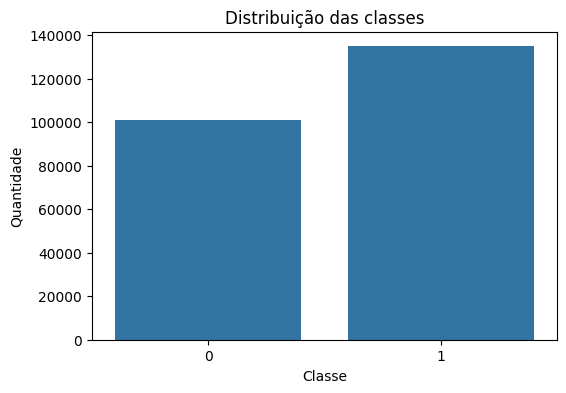

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="label")

plt.title("Distribuição das classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

### Variáveis categóricas

As colunas categóricas identificadas deverão receber tratamento específico antes do treinamento dos modelos, uma vez que os algoritmos utilizados na disciplina trabalham com dados numéricos.

In [ ]:
# Separando atributos numéricos e categóricos

numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categoricas = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Atributos numéricos: {len(numericas)}")
print(f"Atributos categóricos: {len(categoricas)}")

Atributos numéricos: 51
Atributos categóricos: 4


In [ ]:
print("Atributos categóricos:\n")

for coluna in categoricas:
    print("-", coluna)

Atributos categóricos:

- URL
- Domain
- TLD
- Title


In [ ]:
print("Atributos numéricos:\n")

for coluna in numericas:
    print("-", coluna)

Atributos numéricos:

- URLLength
- DomainLength
- IsDomainIP
- URLSimilarityIndex
- CharContinuationRate
- TLDLegitimateProb
- URLCharProb
- TLDLength
- NoOfSubDomain
- HasObfuscation
- NoOfObfuscatedChar
- ObfuscationRatio
- NoOfLettersInURL
- LetterRatioInURL
- NoOfDegitsInURL
- DegitRatioInURL
- NoOfEqualsInURL
- NoOfQMarkInURL
- NoOfAmpersandInURL
- NoOfOtherSpecialCharsInURL
- SpacialCharRatioInURL
- IsHTTPS
- LineOfCode
- LargestLineLength
- HasTitle
- DomainTitleMatchScore
- URLTitleMatchScore
- HasFavicon
- Robots
- IsResponsive
- NoOfURLRedirect
- NoOfSelfRedirect
- HasDescription
- NoOfPopup
- NoOfiFrame
- HasExternalFormSubmit
- HasSocialNet
- HasSubmitButton
- HasHiddenFields
- HasPasswordField
- Bank
- Pay
- Crypto
- HasCopyrightInfo
- NoOfImage
- NoOfCSS
- NoOfJS
- NoOfSelfRef
- NoOfEmptyRef
- NoOfExternalRef
- label


## Conclusão da compreensão dos dados

A análise inicial permitiu conhecer a estrutura do conjunto de dados, identificar os tipos das variáveis e verificar possíveis problemas, como valores ausentes e registros duplicados.

Também foi possível observar a distribuição da variável alvo, informação essencial para definir a estratégia de treinamento dos modelos de classificação.

Na próxima etapa será realizada a Análise Exploratória dos Dados, utilizando gráficos e medidas estatísticas para investigar relações entre os atributos e a variável alvo.

# 3. Análise Exploratória dos Dados

Nesta etapa são realizadas análises gráficas e estatísticas para compreender melhor o comportamento dos atributos do conjunto de dados.

O objetivo é identificar padrões, relações entre variáveis, possíveis valores extremos e características que possam influenciar o desempenho dos modelos de aprendizado de máquina.

In [ ]:
# Separando variáveis numéricas e categóricas

numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categoricas = df.select_dtypes(include=["object"]).columns.tolist()

# Remove o atributo alvo da lista numérica, caso esteja presente
if "label" in numericas:
    numericas.remove("label")

In [ ]:
print(f"Variáveis numéricas: {len(numericas)}")
print(f"Variáveis categóricas: {len(categoricas)}")

Variáveis numéricas: 50
Variáveis categóricas: 4


## Distribuição das classes

O primeiro passo consiste em verificar se existe balanceamento entre as classes do atributo alvo.

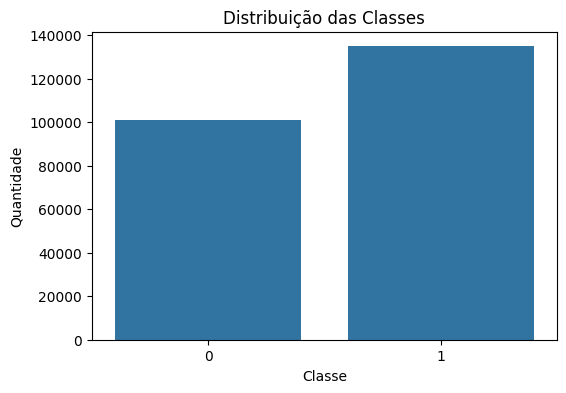

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="label")

plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

### Interpretação

Este gráfico mostra a quantidade de registros pertencentes a cada classe.

Caso exista uma diferença muito grande entre elas, o conjunto de dados é considerado desbalanceado, podendo afetar o desempenho dos classificadores.

## Histogramas

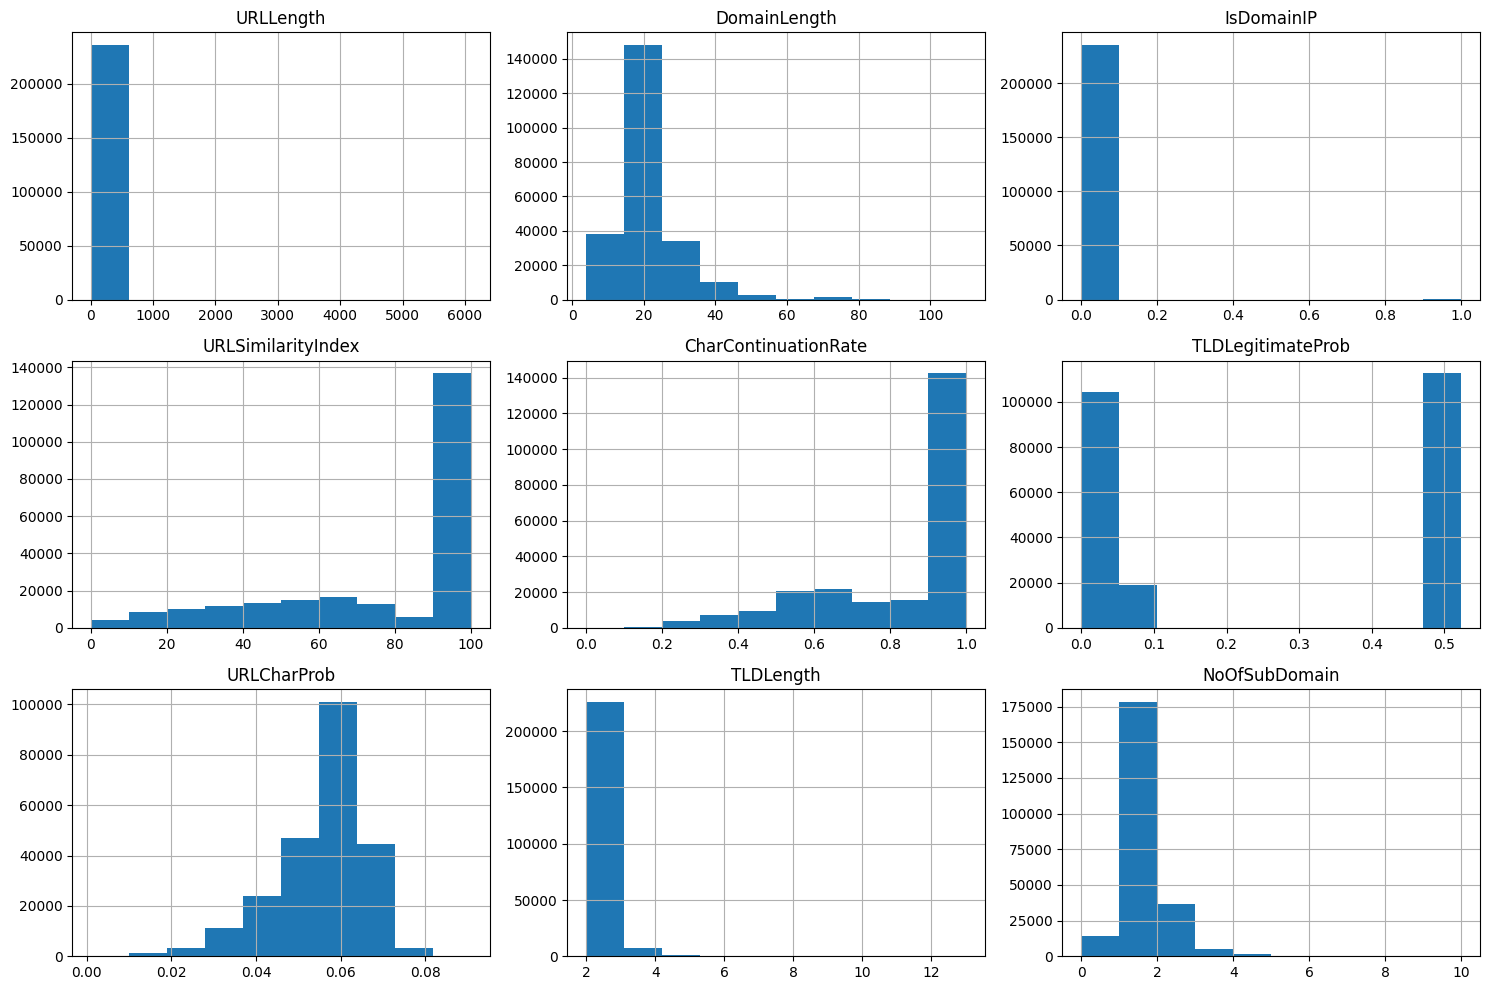

In [ ]:
# Primeiras 9 variáveis numéricas

df[numericas[:9]].hist(figsize=(15,10))

plt.tight_layout()

plt.show()

Os histogramas permitem observar como os valores de cada atributo estão distribuídos.

É possível identificar assimetrias, concentrações de valores e possíveis distribuições não uniformes.

## Boxplots

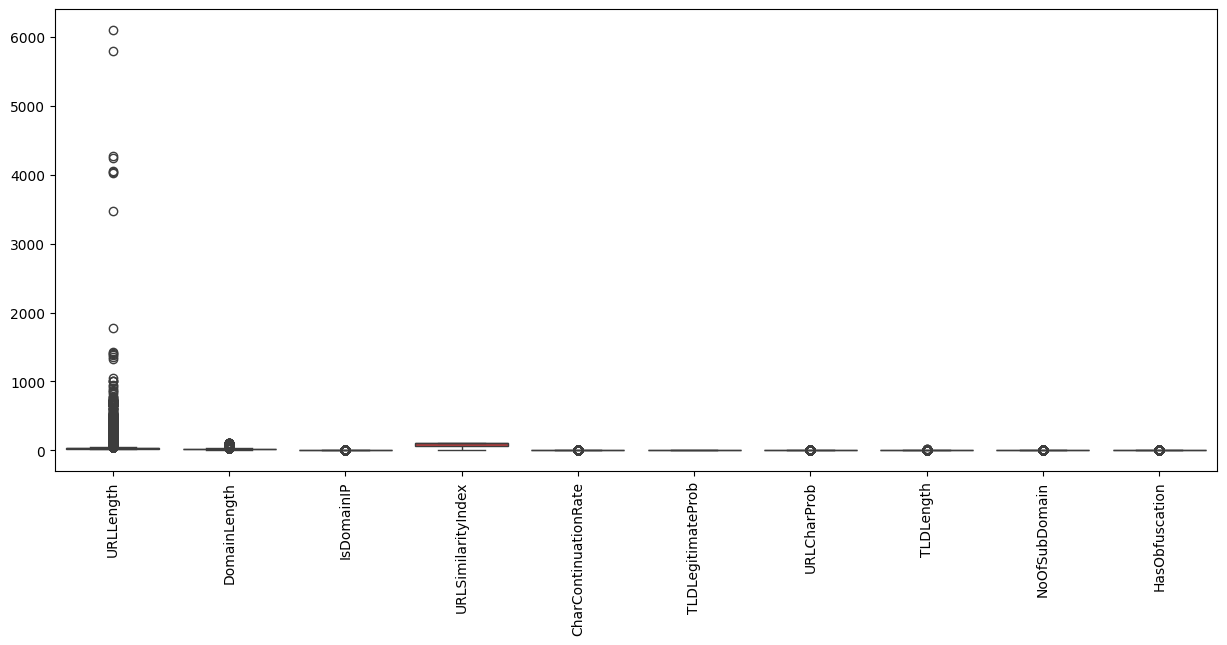

In [ ]:
plt.figure(figsize=(15,6))

sns.boxplot(data=df[numericas[:10]])

plt.xticks(rotation=90)

plt.show()

Os boxplots permitem identificar possíveis valores extremos (outliers), além da dispersão dos dados e da posição da mediana de cada variável.

## Correlação entre atributos

In [ ]:
correlacao = df[numericas].corr()

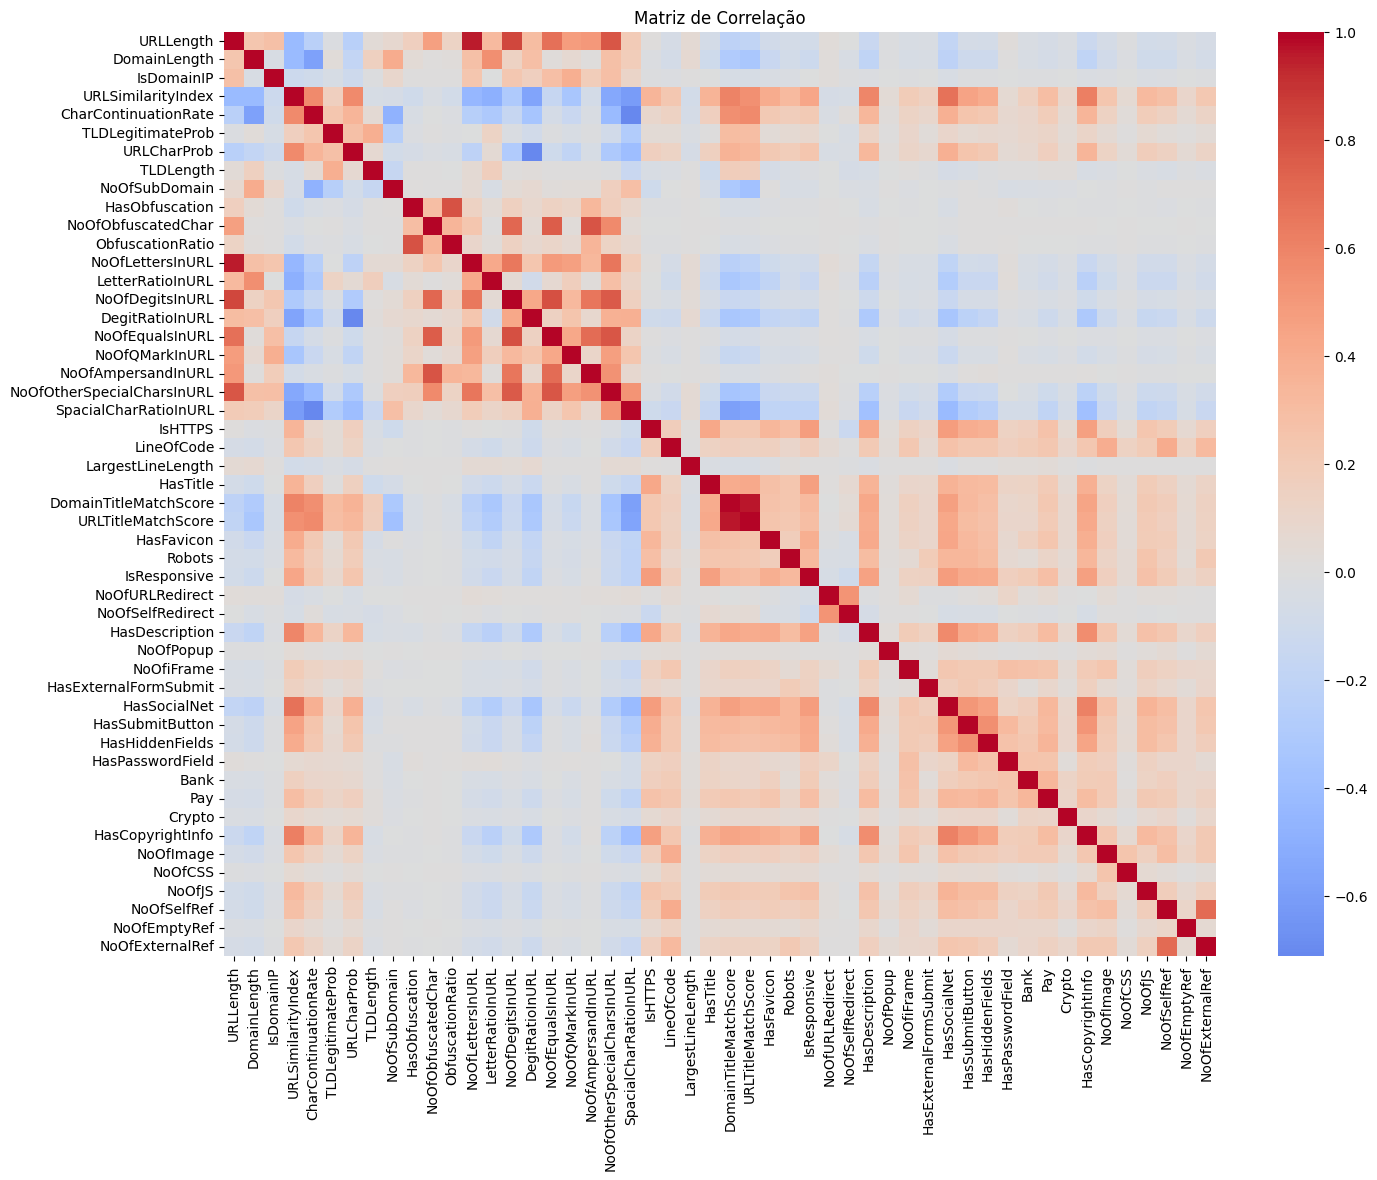

In [ ]:
plt.figure(figsize=(16,12))

sns.heatmap(
    correlacao,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação")

plt.show()

A matriz de correlação permite verificar relações lineares entre os atributos.

Valores próximos de 1 indicam forte correlação positiva, enquanto valores próximos de -1 indicam forte correlação negativa.

Correlação próxima de zero indica pouca relação linear.

## Correlação com a variável alvo

In [ ]:
corr_label = df.corr(numeric_only=True)["label"].sort_values(ascending=False)

corr_label

,label
label,1.000000
URLSimilarityIndex,0.860358
HasSocialNet,0.784255
HasCopyrightInfo,0.743358
HasDescription,0.690232
IsHTTPS,0.609132
DomainTitleMatchScore,0.584905
HasSubmitButton,0.578561
IsResponsive,0.548608
URLTitleMatchScore,0.539419


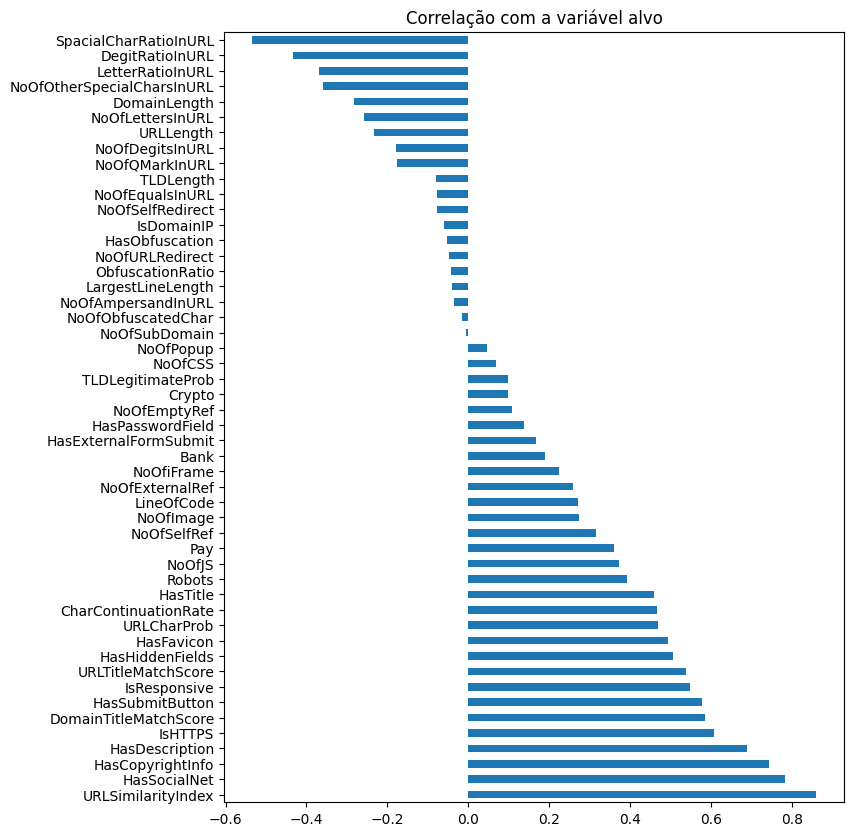

In [ ]:
plt.figure(figsize=(8,10))

corr_label.drop("label").plot(kind="barh")

plt.title("Correlação com a variável alvo")

plt.show()

Este gráfico apresenta quais atributos possuem maior relação linear com a variável alvo.

Esses atributos tendem a fornecer informações mais relevantes para os modelos de classificação.

## Distribuição de algumas variáveis importantes por classe

In [ ]:
# Seleciona as quatro variáveis mais correlacionadas (exceto label)

top4 = corr_label.drop("label").abs().sort_values(ascending=False).head(4).index

top4

Index(['URLSimilarityIndex', 'HasSocialNet', 'HasCopyrightInfo',
       'HasDescription'],
      dtype='object')

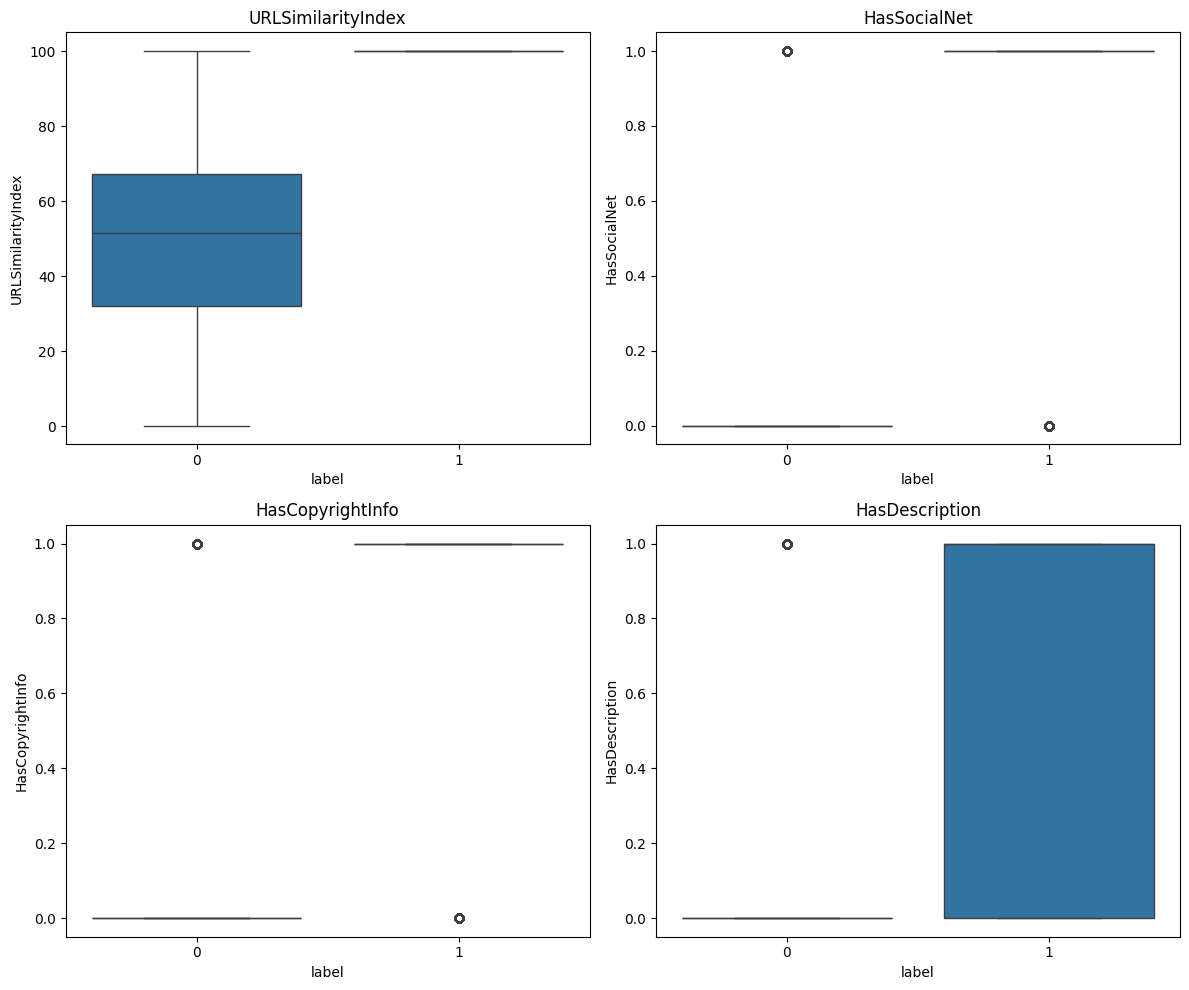

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

for ax, coluna in zip(axes.flatten(), top4):

    sns.boxplot(
        data=df,
        x="label",
        y=coluna,
        ax=ax
    )

    ax.set_title(coluna)

plt.tight_layout()

plt.show()

Os gráficos permitem comparar a distribuição das variáveis mais relevantes entre as diferentes classes.

Quando existe uma separação visível entre as distribuições das classes, espera-se que os algoritmos consigam aprender essa diferença com maior facilidade.

# Conclusão da Análise Exploratória

A análise exploratória permitiu compreender melhor o comportamento das variáveis do conjunto de dados.

Foram observadas as distribuições dos atributos, a presença de possíveis valores extremos, a correlação entre variáveis e a relação entre os atributos e a variável alvo.

Essas informações serão utilizadas na etapa seguinte para definir as estratégias de pré-processamento e preparação dos dados para o treinamento dos modelos.

# 4. Pré-processamento

Nesta etapa são realizados os tratamentos necessários para preparar os dados para o treinamento dos modelos.

Os principais procedimentos incluem:

- separação entre atributos preditivos e atributo alvo;
- identificação das variáveis numéricas e categóricas;
- tratamento de valores ausentes;
- codificação das variáveis categóricas;
- escalonamento dos atributos numéricos;
- separação entre treino e teste.

Todo o pré-processamento será realizado utilizando um Pipeline do Scikit-Learn para evitar vazamento de informações entre os conjuntos de treinamento e teste.

In [ ]:
from sklearn.model_selection import train_test_split

TARGET = "label"

X = df.drop(columns=[TARGET])
y = df[TARGET]

## Separação entre treino e teste

Os dados são separados antes do treinamento dos modelos.

Foi utilizada uma divisão de 80% para treinamento e 20% para teste.

Como o problema é de classificação, foi utilizada estratificação para manter a proporção das classes em ambos os conjuntos.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [ ]:
print("Treinamento:", X_train.shape)
print("Teste:", X_test.shape)

Treinamento: (188636, 54)
Teste: (47159, 54)


## Identificação dos tipos de atributos

In [ ]:
numericas = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categoricas = X_train.select_dtypes(
    include=["object"]
).columns

print(f"Atributos numéricos: {len(numericas)}")
print(f"Atributos categóricos: {len(categoricas)}")

Atributos numéricos: 50
Atributos categóricos: 4


## Pipeline para atributos numéricos

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pipeline_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

Os atributos numéricos recebem dois tratamentos:

- substituição de valores ausentes pela mediana;
- padronização utilizando StandardScaler.

A padronização é importante principalmente para o algoritmo SGDClassifier, que é sensível à escala dos atributos.

## Pipeline para atributos categóricos

In [ ]:
from sklearn.preprocessing import OneHotEncoder

pipeline_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

As variáveis categóricas recebem:

- preenchimento de valores ausentes pela categoria mais frequente;
- codificação One-Hot Encoding.

Essa transformação converte categorias em variáveis numéricas, permitindo que sejam utilizadas pelos algoritmos de classificação.

## Construção do ColumnTransformer

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, numericas),
        ("cat", pipeline_categorico, categoricas)
    ]
)

## Aplicação do pré-processamento

In [ ]:
X_train_preparado = preprocessador.fit_transform(X_train)

X_test_preparado = preprocessador.transform(X_test)

In [ ]:
print(X_train_preparado.shape)
print(X_test_preparado.shape)

(188636, 525046)
(47159, 525046)


O método `fit_transform()` foi aplicado apenas ao conjunto de treinamento.

O conjunto de teste foi transformado utilizando apenas `transform()`, garantindo que nenhuma informação do teste seja utilizada durante o treinamento dos modelos e evitando vazamento de dados.

# Conclusão

Após o pré-processamento, os dados encontram-se preparados para o treinamento dos modelos de aprendizado de máquina.

Todas as transformações foram realizadas utilizando um Pipeline do Scikit-Learn, garantindo organização do código e evitando vazamento de informações entre os conjuntos de treinamento e teste.

# 5. Modelagem

Nesta etapa serão treinados três modelos de classificação:

- Baseline (DummyClassifier)
- SGDClassifier
- RandomForestClassifier

O objetivo é comparar o desempenho entre eles e selecionar o modelo mais adequado para o problema.

Todos os modelos utilizarão o mesmo pipeline de pré-processamento, garantindo que as transformações sejam aplicadas de maneira consistente e evitando vazamento de informações.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

## Estratégia de Validação

Será utilizada validação cruzada estratificada com cinco partições (5-Fold Stratified Cross Validation).

Essa estratégia reduz a dependência de uma única divisão entre treino e teste, produzindo uma estimativa mais confiável do desempenho dos modelos.

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Baseline

In [ ]:
pipeline_dummy = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", DummyClassifier(strategy="most_frequent"))
])

In [ ]:
dummy_scores = cross_val_score(
    pipeline_dummy,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print(dummy_scores)
print(f"Acurácia média: {dummy_scores.mean():.4f}")

[0.57188295 0.57189811 0.57189811 0.57189811 0.57189811]
Acurácia média: 0.5719


O DummyClassifier serve como modelo de referência.

Ele sempre prevê a classe mais frequente, permitindo verificar se os modelos de aprendizado realmente conseguem superar um comportamento trivial.

## SGDClassifier

In [ ]:
pipeline_sgd = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo",
     SGDClassifier(
         loss="log_loss",
         random_state=42,
         max_iter=1000
     ))
])

In [ ]:
sgd_scores = cross_val_score(
    pipeline_sgd,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print(sgd_scores)
print(f"Acurácia média: {sgd_scores.mean():.4f}")

[0.99976145 0.99978795 0.99970843 0.99970843 0.99994699]
Acurácia média: 0.9998


O SGDClassifier é um algoritmo eficiente para grandes conjuntos de dados.

Sua utilização foi exigida pela disciplina e seu desempenho será comparado ao dos demais modelos.

## Random Forest

In [ ]:
pipeline_rf = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo",
     RandomForestClassifier(
         n_estimators=200,
         random_state=42,
         n_jobs=-1
     ))
])

In [ ]:
rf_scores = cross_val_score(
    pipeline_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print(rf_scores)
print(f"Acurácia média: {rf_scores.mean():.4f}")

[1.         0.99992048 0.99989398 0.99981446 0.99989398]
Acurácia média: 0.9999


O Random Forest combina diversas árvores de decisão, reduzindo o risco de overfitting e aumentando a capacidade de generalização do modelo.

Esse algoritmo também faz parte dos modelos mínimos exigidos pela disciplina.

## Comparação dos modelos

In [ ]:
import pandas as pd

comparacao = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "SGDClassifier",
        "Random Forest"
    ],
    "Acurácia Média": [
        dummy_scores.mean(),
        sgd_scores.mean(),
        rf_scores.mean()
    ]
})

comparacao = comparacao.sort_values(
    by="Acurácia Média",
    ascending=False
)

comparacao

,Modelo,Acurácia Média
2,Random Forest,0.999905
1,SGDClassifier,0.999783
0,Baseline,0.571895


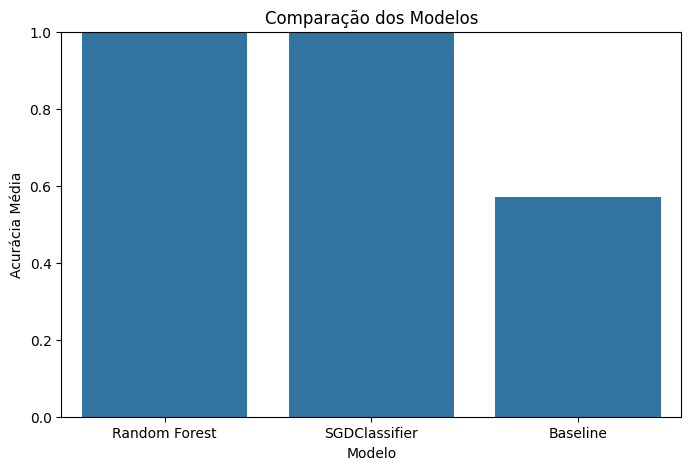

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparacao,
    x="Modelo",
    y="Acurácia Média"
)

plt.ylim(0,1)

plt.title("Comparação dos Modelos")

plt.show()

### Discussão

A comparação permite verificar qual algoritmo apresentou melhor desempenho durante a validação cruzada.

O modelo que obtiver a maior acurácia média será utilizado na etapa seguinte para a avaliação final utilizando o conjunto de teste.

## Conclusão

Os modelos foram treinados utilizando validação cruzada estratificada e comparados por meio da acurácia média.

Na próxima etapa será realizada a avaliação final utilizando o conjunto de teste, empregando métricas como matriz de confusão, acurácia, precisão, revocação e F1-score.

# 6. Avaliação dos Modelos

Nesta etapa será realizada a avaliação final do modelo selecionado utilizando o conjunto de teste.

Serão utilizadas as seguintes métricas:

- Acurácia
- Precisão
- Revocação (Recall)
- F1-score
- Matriz de Confusão

Essas métricas permitem avaliar o desempenho do classificador sob diferentes perspectivas.

In [ ]:
# Dicionário com os modelos

modelos = {
    "Baseline": (pipeline_dummy, dummy_scores.mean()),
    "SGDClassifier": (pipeline_sgd, sgd_scores.mean()),
    "Random Forest": (pipeline_rf, rf_scores.mean())
}

In [ ]:
# Seleciona automaticamente o melhor modelo

nome_modelo, (melhor_modelo, melhor_score) = max(
    modelos.items(),
    key=lambda item: item[1][1]
)

print(f"Melhor modelo: {nome_modelo}")
print(f"Acurácia média (CV): {melhor_score:.4f}")

Melhor modelo: Random Forest
Acurácia média (CV): 0.9999


O modelo selecionado foi aquele que apresentou a maior acurácia média durante a validação cruzada.

In [ ]:
# Treinamento final

melhor_modelo.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex',
       'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength',
       'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscate...
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef',
       'NoOfExternalRef'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['URL', 'Domain', 'TLD', 'Title'], dtype='object'))])),
                ('modelo',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [ ]:
# Predições

y_pred = melhor_modelo.predict(X_test)

##Acurácia

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia: {accuracy:.4f}")

Acurácia: 0.9999


##Precisão

In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Precisão: {precision:.4f}")

Precisão: 0.9999


##Recall

In [ ]:
recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Recall: {recall:.4f}")

Recall: 0.9999


##F1

In [ ]:
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"F1-Score: {f1:.4f}")

F1-Score: 0.9999


##Relatório completo

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



##Matriz de confução

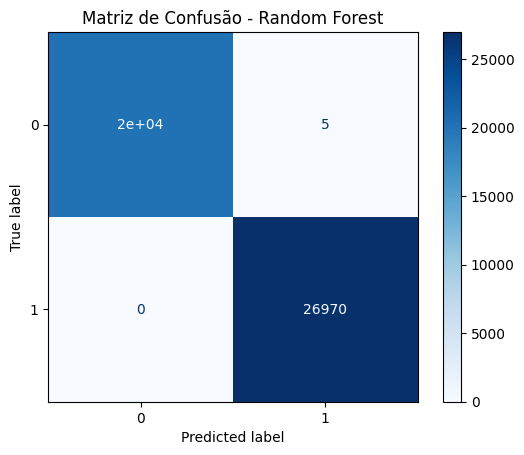

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title(f"Matriz de Confusão - {nome_modelo}")

plt.show()

##Tabela de métricas

In [ ]:
metricas = pd.DataFrame({
    "Métrica": [
        "Acurácia",
        "Precisão",
        "Recall",
        "F1-Score"
    ],
    "Valor": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metricas

,Métrica,Valor
0,Acurácia,0.999894
1,Precisão,0.999894
2,Recall,0.999894
3,F1-Score,0.999894


##Gráfico

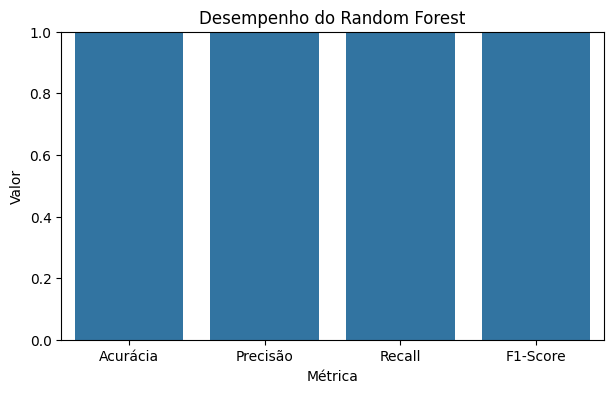

In [ ]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=metricas,
    x="Métrica",
    y="Valor"
)

plt.ylim(0,1)

plt.title(f"Desempenho do {nome_modelo}")

plt.show()

## Discussão dos Resultados

Os modelos avaliados apresentaram desempenhos bastante distintos.

O Baseline, que sempre prevê a classe mais frequente, obteve acurácia média de aproximadamente **57,19%**, servindo como referência para comparação.

O SGDClassifier apresentou desempenho significativamente superior ao baseline, alcançando uma acurácia média de **99,98%** durante a validação cruzada.

O Random Forest foi o modelo que apresentou o melhor desempenho, com acurácia média de **99,99%**, sendo selecionado para a avaliação final no conjunto de teste.

Na avaliação final, o modelo manteve excelente desempenho, obtendo:

- Acurácia: 99,99%
- Precisão: 99,99%
- Recall: 99,99%
- F1-Score: 99,99%

Esses resultados indicam que o modelo conseguiu identificar corretamente praticamente todas as URLs presentes no conjunto de teste.

A matriz de confusão mostra que apenas **5 URLs legítimas foram classificadas incorretamente como phishing**, enquanto **nenhuma URL de phishing foi classificada como legítima**.

## Conclusão

Neste trabalho foram comparados diferentes algoritmos de aprendizado de máquina para o problema de detecção de URLs de phishing.

Os resultados demonstraram que ambos os algoritmos de aprendizado superaram amplamente o modelo baseline, comprovando sua capacidade de aprender padrões presentes nos dados.

Entre os modelos avaliados, o Random Forest apresentou o melhor desempenho, alcançando aproximadamente 99,99% de acurácia e apresentando apenas cinco classificações incorretas em mais de 47 mil exemplos utilizados para teste.

Esse desempenho pode ser explicado pela capacidade do Random Forest de modelar relações não lineares entre os diversos atributos presentes no conjunto de dados, além de sua robustez frente a diferentes tipos de variáveis.

Embora os resultados sejam excelentes, valores de desempenho muito elevados devem sempre ser analisados com cautela. Em aplicações reais, recomenda-se validar o modelo utilizando novos conjuntos de dados provenientes de outras fontes, garantindo sua capacidade de generalização.

# 7. Considerações Finais

O objetivo deste trabalho foi desenvolver e avaliar modelos de aprendizado de máquina capazes de classificar URLs como legítimas ou maliciosas, utilizando o conjunto de dados **PhiUSIIL Phishing URL Dataset**.

Durante o desenvolvimento do projeto foram realizadas as etapas de compreensão dos dados, análise exploratória, pré-processamento, treinamento e avaliação dos modelos, seguindo as boas práticas de projetos de aprendizado de máquina.

Foram comparados três modelos de classificação: Baseline (DummyClassifier), SGDClassifier e Random Forest. A comparação demonstrou que os modelos de aprendizado apresentaram desempenho muito superior ao modelo baseline.

Entre os algoritmos avaliados, o Random Forest apresentou os melhores resultados, alcançando aproximadamente **99,99% de acurácia**, além de elevados valores de precisão, recall e F1-score.

A matriz de confusão evidenciou apenas cinco classificações incorretas no conjunto de teste, indicando excelente capacidade de generalização para os dados utilizados.

Os resultados obtidos demonstram que técnicas de aprendizado de máquina podem ser empregadas com elevada eficiência na identificação automática de URLs de phishing, contribuindo para sistemas de segurança digital e proteção contra ataques cibernéticos.

## Limitações

Apesar do excelente desempenho obtido, algumas limitações devem ser consideradas.

Os modelos foram avaliados utilizando apenas um conjunto de dados específico. Em aplicações reais, novas técnicas de phishing surgem constantemente, tornando necessário validar o modelo em bases mais recentes e diversificadas.

Além disso, não foi realizada uma otimização completa dos hiperparâmetros dos algoritmos, o que poderia resultar em melhorias adicionais de desempenho.

## Referências

PRASAD, A.; CHANDRA, S.

PhiUSIIL Phishing URL Dataset.

UCI Machine Learning Repository, 2024.

Scikit-Learn Developers.

Scikit-Learn Machine Learning in Python.

https://scikit-learn.org/

Pedregosa et al.

Scikit-learn: Machine Learning in Python.

Journal of Machine Learning Research, 2011.

## Declaração do Uso de Inteligência Artificial

Durante o desenvolvimento deste trabalho foi utilizada a ferramenta ChatGPT como apoio para esclarecimento de dúvidas, organização do notebook, estruturação das etapas do projeto e revisão do código.

Todo o conteúdo gerado foi analisado, adaptado e validado pelos integrantes do grupo antes de sua utilização no trabalho final.